# UK Economic Pulse

## Goal: understand what the hell is going on with the economy

### Methods: 

### 1. Trend the latest macro variables across 4 broad areas

#### 1.1 Economic Activity

GDP (US), 
GDP (UK), 
House Prices (UK)

#### 1.2 Inflation Pressure

CPI (UK), Real Wages (UK), Unemployment (UK), Consumer Confidence, Labour Participation

#### 1.3 Financial Conditions

Base Rate (UK), 10Y Yield (UK), 10Y Yield (US)

#### 1.4 Commodity Prices

Oil, Gold, Silver, Copper, Natural Gas

### 2. Devise a composite metric of these to track the actual pulse of the economy



# Step 1: Get the Macro Data

In [1]:
# UK Economic Pulse - Building the Core Logic Step by Step

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred


# Need pandas to connect to dataframes
# Matplotlib is sufficient for simple visualisations
# Fred will give us the data

import io
import re
import requests


In [2]:
# FRED_API_KEY = os.getenv("FRED_API_KEY")  # or paste your key as a string for now
FRED_API_KEY = '0acae73adc29df31d82dce5320829f70'
fred = Fred(api_key=FRED_API_KEY)

# Why is it cleaner to use an environment variable?

# Step 1.1: Get GDP

We get data from FRED's API, published quarterly

In [3]:
gdp = fred.get_series("NGDPRSAXDCGBQ")
gdp.head(), gdp.tail()

# Date index
# Float values
# Updated quarterly

(1955-01-01    145457.0
 1955-04-01    145551.0
 1955-07-01    147995.0
 1955-10-01    147119.0
 1956-01-01    148955.0
 dtype: float64,
 2024-10-01    698780.0
 2025-01-01    703373.0
 2025-04-01    704798.0
 2025-07-01    705187.0
 2025-10-01    705571.0
 dtype: float64)

In [4]:
print(type(gdp))
print(gdp.index.min(), gdp.index.max())
print(gdp.isna().sum())
print(pd.infer_freq(gdp.index))

# Class: Series
# Inferred frequency: Quarters
# No gaps

<class 'pandas.core.series.Series'>
1955-01-01 00:00:00 2025-10-01 00:00:00
0
QS-OCT


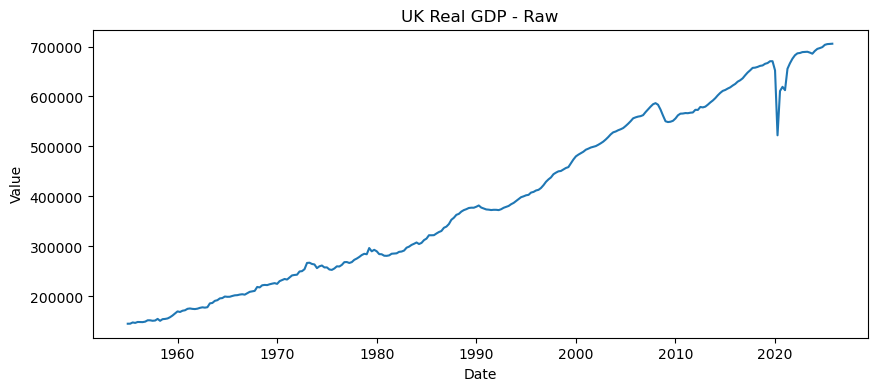

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(gdp.index, gdp.values)
plt.title("UK Real GDP - Raw")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Clear recessions in almost every decade, with the worst being the pandemic, by far

In [ ]:
# Economic Activity

gdp = fred.get_series("NGDPRSAXDCGBQ")
gdp_us = fred.get_series("GDPC1")
house_prices = fred.get_series("QGBR628BIS")

# Step 1.2: Get Oil Prices

We get oil prices from FRED's API, published daily

In [6]:
oil = fred.get_series("DCOILBRENTEU")

# Why is it useful to compare mixed frequencies?
# What problem will this create later?

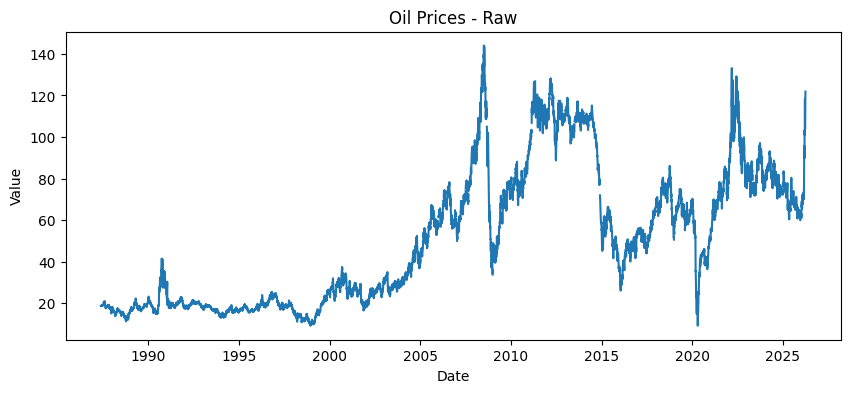

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(oil.index, oil.values)
plt.title("Oil Prices - Raw")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Massive increease since the turn of the century
# Steady incline since 2025 briefly impacted by the pandemic

# Step 1.3: Get UK Inflation Data

We extract a csv from ONS, generally published on the fourth week of every month

In [8]:
import re
import pandas as pd
import requests
import io

# -----------------------------
# 1) ONS CPI (index level)
# Series: D7BT = CPI INDEX 00: ALL ITEMS 2015=100
# Source dataset: MM23
# -----------------------------

def get_uk_cpi_index_ons() -> pd.Series:
    url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/inflationandpriceindices/timeseries/d7bt/mm23"
    
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    df = pd.read_csv(io.StringIO(r.text))

    # Rename the two columns into something sane
    df.columns = ["raw_date", "raw_value"]

    # Keep only monthly rows like '1988 JAN'
    monthly_mask = df["raw_date"].astype(str).str.match(r"^\d{4} [A-Z]{3}$")
    df = df.loc[monthly_mask].copy()

    # Rename
    df = df.rename(columns={
        "raw_date": "date",
        "raw_value": "cpi_index"
    })

    # Parse fields
    df["date"] = pd.to_datetime(df["date"], format="%Y %b", errors="coerce")
    df["cpi_index"] = pd.to_numeric(df["cpi_index"], errors="coerce")

    # Clean up
    df = df.dropna(subset=["date", "cpi_index"]).sort_values("date")
    df = df.set_index("date")

    s = df["cpi_index"]
    s.name = "cpi_index"
    return s

In [9]:
# -----------------------------
# 2) ONS CPI YoY inflation
# Derived from the CPI index
# -----------------------------

def make_cpi_yoy(cpi_index: pd.Series) -> pd.Series:
    cpi_yoy = cpi_index.pct_change(12) * 100
    cpi_yoy.name = "cpi_yoy"
    return cpi_yoy

# Step 1.4: Get Bank of England Rates

We pull from the Bank's history page

In [12]:
import lxml

# -----------------------------
# 3) Bank of England policy rate
# Pull from the official Bank Rate history page
# -----------------------------

import io
import time
import requests
import pandas as pd

def get_boe_policy_rate(local_fallback_path=None) -> pd.Series:
    url = "https://www.bankofengland.co.uk/boeapps/database/Bank-Rate.asp"

    session = requests.Session()
    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0.0.0 Safari/537.36"
        ),
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-GB,en;q=0.9",
        "Referer": "https://www.bankofengland.co.uk/boeapps/database/",
        "Connection": "keep-alive",
    })

    # First hit the database home page to look less like a bot
    try:
        warmup = session.get(
            "https://www.bankofengland.co.uk/boeapps/database/",
            timeout=30
        )
        warmup.raise_for_status()
        time.sleep(1.0)
    except Exception:
        pass

    try:
        r = session.get(url, timeout=30)
        r.raise_for_status()

        tables = pd.read_html(io.StringIO(r.text))
        if not tables:
            raise ValueError("No tables found on Bank Rate page.")

        df = tables[0].copy()
        df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]

        if "date_changed" not in df.columns or "rate" not in df.columns:
            raise ValueError(f"Unexpected columns on Bank Rate page: {list(df.columns)}")

        df["date_changed"] = pd.to_datetime(df["date_changed"], format="%d %b %y", errors="coerce")
        df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

        df = df.dropna(subset=["date_changed", "rate"]).sort_values("date_changed")
        df = df.set_index("date_changed")

        s = df["rate"]
        s.name = "policy_rate"
        return s

    except requests.HTTPError as e:
        if local_fallback_path is None:
            raise RuntimeError(
                f"BoE request blocked with HTTP {e.response.status_code}. "
                "Download the Bank Rate history CSV manually from the BoE page and pass its path "
                "as local_fallback_path."
            ) from e

        # Fallback: read a manually downloaded BoE CSV
        raw = pd.read_csv(local_fallback_path)

        # Adjust if your CSV comes with slightly different column names
        raw.columns = [str(c).strip().lower().replace(" ", "_") for c in raw.columns]

        # Try common variants
        date_col = next((c for c in raw.columns if c in ["date_changed", "date"]), None)
        rate_col = next((c for c in raw.columns if c in ["rate", "value"]), None)

        if date_col is None or rate_col is None:
            raise ValueError(
                f"Could not identify date/rate columns in fallback CSV: {list(raw.columns)}"
            )

        df = raw[[date_col, rate_col]].copy()
        df.columns = ["date_changed", "rate"]

        df["date_changed"] = pd.to_datetime(df["date_changed"], errors="coerce", dayfirst=True)
        df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

        df = df.dropna(subset=["date_changed", "rate"]).sort_values("date_changed")
        df = df.set_index("date_changed")

        s = df["rate"]
        s.name = "policy_rate"
        return s

In [13]:
# ----------------------------- 
# 4) Convert policy rate changes to month-end series 
# -----------------------------

def make_policy_rate_monthly(policy_rate_changes: pd.Series, end_date=None) -> pd.Series:
    monthly = policy_rate_changes.resample("ME").last()

    if end_date is None:
        end_date = pd.Timestamp.today().to_period("M").to_timestamp("M")

    full_index = pd.date_range(start=monthly.index.min(), end=end_date, freq="ME")

    monthly = monthly.reindex(full_index).ffill()
    monthly.name = "policy_rate"
    return monthly

# Step 2: Pull the Metrics Together

In [14]:
# -----------------------------
# 5) Pull everything together
# -----------------------------

cpi_index = get_uk_cpi_index_ons()
policy_rate_changes = get_boe_policy_rate()
policy_rate_monthly = make_policy_rate_monthly(policy_rate_changes)

print("CPI index last date:", cpi_index.last_valid_index())
print("Policy rate change table last date:", policy_rate_changes.last_valid_index())
print("Policy rate monthly last date:", policy_rate_monthly.last_valid_index())

display(cpi_index.tail())
display(policy_rate_changes.tail())print("CPI YoY last date:", cpi_yoy.last_valid_index())

display(policy_rate_monthly.tail())

CPI index last date: 2026-02-01 00:00:00
CPI YoY last date: 2026-02-01 00:00:00
Policy rate change table last date: 2025-12-18 00:00:00
Policy rate monthly last date: 2026-04-30 00:00:00


date
2025-10-01    139.8
2025-11-01    139.5
2025-12-01    140.1
2026-01-01    139.5
2026-02-01    140.1
Name: cpi_index, dtype: float64

date
2025-10-01    3.555556
2025-11-01    3.256847
2025-12-01    3.318584
2026-01-01    3.028065
2026-02-01    3.014706
Name: cpi_yoy, dtype: float64

date_changed
2024-11-07    4.75
2025-02-06    4.50
2025-05-08    4.25
2025-08-07    4.00
2025-12-18    3.75
Name: policy_rate, dtype: float64

2025-12-31    3.75
2026-01-31    3.75
2026-02-28    3.75
2026-03-31    3.75
2026-04-30    3.75
Freq: ME, Name: policy_rate, dtype: float64

# Step 2.1: Inspect the frequency of each series

In [ ]:
for name, s in {
    "GDP (UK)": gdp,
    "GDP (US)": gdp_us,
    "House Prices (UK)": house_prices,
    "CPI (UK)": cpi_index,
    "Oil": oil,
    "Base Rate (UK)": policy_rate_monthly
}.items():
    print(name)
    print("Start:", s.index.min())
    print("End:", s.index.max())
    print("Missing:", s.isna().sum())
    print("Inferred freq:", pd.infer_freq(s.index[:20]) if len(s) > 20 else pd.infer_freq(s.index))
    print("-" * 40)

# GDP: Quarterly
# CPI: Monthly, stops after 2025-03-01
# Oil: Business Days
# Base Rate: Monthly

# I can take the month-end values for inflation, oil and the base rate if I want to visualise them side-by-side

# Fun fact: 
# The Bank of England was established in 1694. It's the oldest Central Bank in the world, after the 
# Swedish Central Bank. It was created to raise funds to finance war efforts and manage national debt.


GDP (UK)
Start: 1955-01-01 00:00:00
End: 2025-10-01 00:00:00
Missing: 0
Inferred freq: QS-OCT
----------------------------------------
GDP (US)
Start: 1947-01-01 00:00:00
End: 2025-10-01 00:00:00
Missing: 0
Inferred freq: QS-OCT
----------------------------------------
CPI (UK)
Start: 1988-01-01 00:00:00
End: 2026-02-01 00:00:00
Missing: 0
Inferred freq: MS
----------------------------------------
Oil
Start: 1987-05-20 00:00:00
End: 2026-03-30 00:00:00
Missing: 278
Inferred freq: B
----------------------------------------
Base Rate (UK)
Start: 1975-01-31 00:00:00
End: 2026-04-30 00:00:00
Missing: 0
Inferred freq: ME
----------------------------------------


# Step 2.2: Resample each series to monthly

gdp_monthly created: True
2025-06-30    704798.0
2025-07-31    705187.0
2025-08-31    705187.0
2025-09-30    705187.0
2025-10-31    705571.0
Freq: ME, dtype: float64


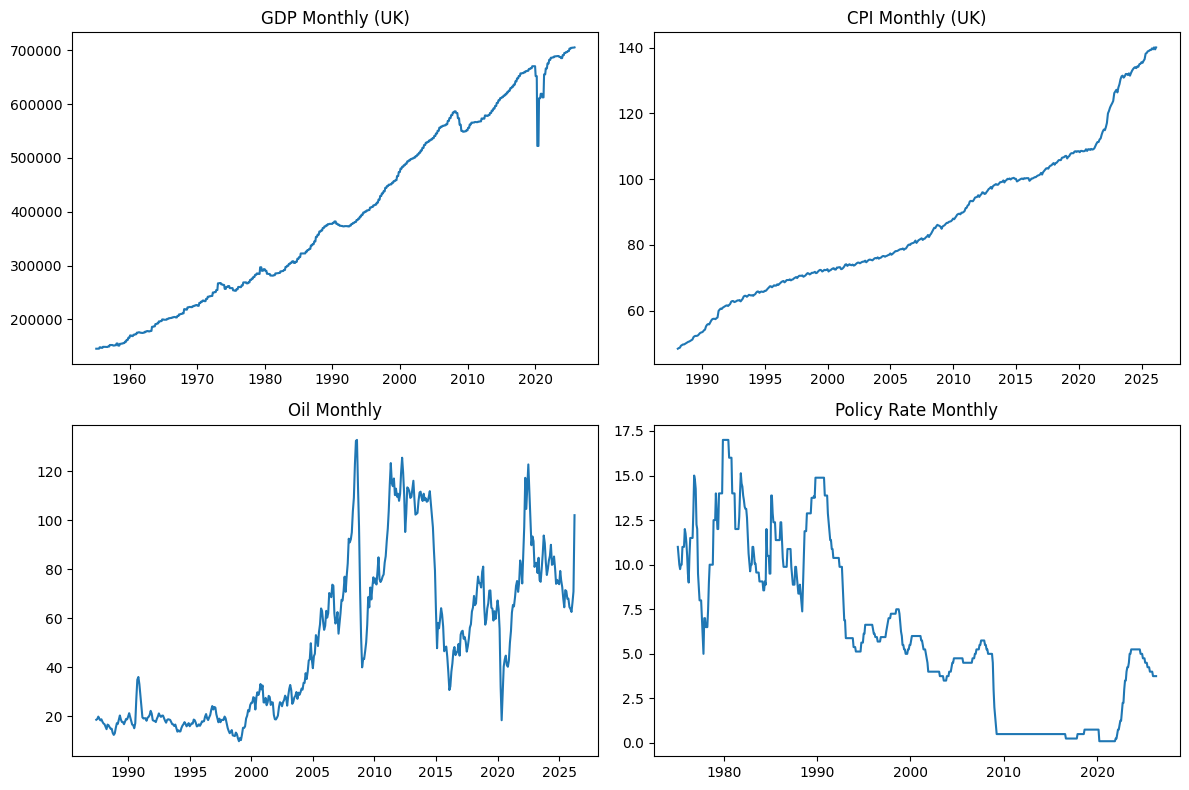

In [70]:
gdp_monthly = gdp.resample("ME").ffill()
gdp_us_monthly = gdp_us.resample("ME").ffill()
cpi_monthly = cpi_index.resample("ME").last()
oil_monthly = oil.resample("ME").mean()
policy_rate_monthly = policy_rate_monthly.copy()

# already monthly, so just keep it

# ffill() for GDP because it's reported Quarterly
# mean() for Oil to capture in-month volatility
# last() for policy rate to capture the final decision made

# What economic assumptions are hidden behind these choices?

# Consider normalising the data 

print("gdp_monthly created:", "gdp_monthly" in globals())
print(gdp_monthly.tail())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

series_dict = {
    "GDP Monthly (UK)": gdp_monthly,
    "CPI Monthly (UK)": cpi_monthly,
    "Oil Monthly": oil_monthly,
    "Policy Rate Monthly": policy_rate_monthly,
    "GDP Monthly (US)": gdp_us_monthly
}

for ax, (title, s) in zip(axes.flatten(), series_dict.items()):
    ax.plot(s.index, s.values)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Step 2.3: Create the dataframe

In [72]:
df = pd.DataFrame({
    "gdp": gdp_monthly,
    "gdp_us": gdp_us_monthly,
    "cpi": cpi_monthly,
    "oil": oil_monthly,
    "policy_rate": policy_rate_monthly
})

df.tail(10)

absolute_values = df

In [19]:
# Check missingness

df.isna().sum()

gdp              6
cpi            398
oil            389
policy_rate    240
dtype: int64

# Step 2.4: Create the signals

In [20]:
signals = pd.DataFrame(index=df.index)

signals["gdp_growth_yoy"] = df["gdp"].pct_change(12) * 100
signals["cpi_yoy"] = df["cpi"].pct_change(12) * 100
signals["oil_yoy"] = df["oil"].pct_change(12) * 100
signals["policy_rate_level"] = df["policy_rate"]

In [21]:

signals.tail(15)

# Which columns have NULLs at the start? Why? Is that acceptable?

,gdp_growth_yoy,cpi_yoy,oil_yoy,policy_rate_level
2025-02-28,1.761434,2.796674,-9.631383,4.50
2025-03-31,1.761434,2.631579,-14.841196,4.50
2025-04-30,1.368945,3.520599,-24.242892,4.50
2025-05-31,1.368945,3.360717,-21.154736,4.25
2025-06-30,1.368945,3.579418,-13.132843,4.25
2025-07-31,1.195948,3.886398,-16.572208,4.25
2025-08-31,1.195948,3.723008,-15.537553,4.00
2025-09-30,1.195948,3.800298,-8.148451,4.00
2025-10-31,0.971837,3.555556,-14.661838,4.00
2025-11-30,NaN,3.256847,-14.188183,4.00


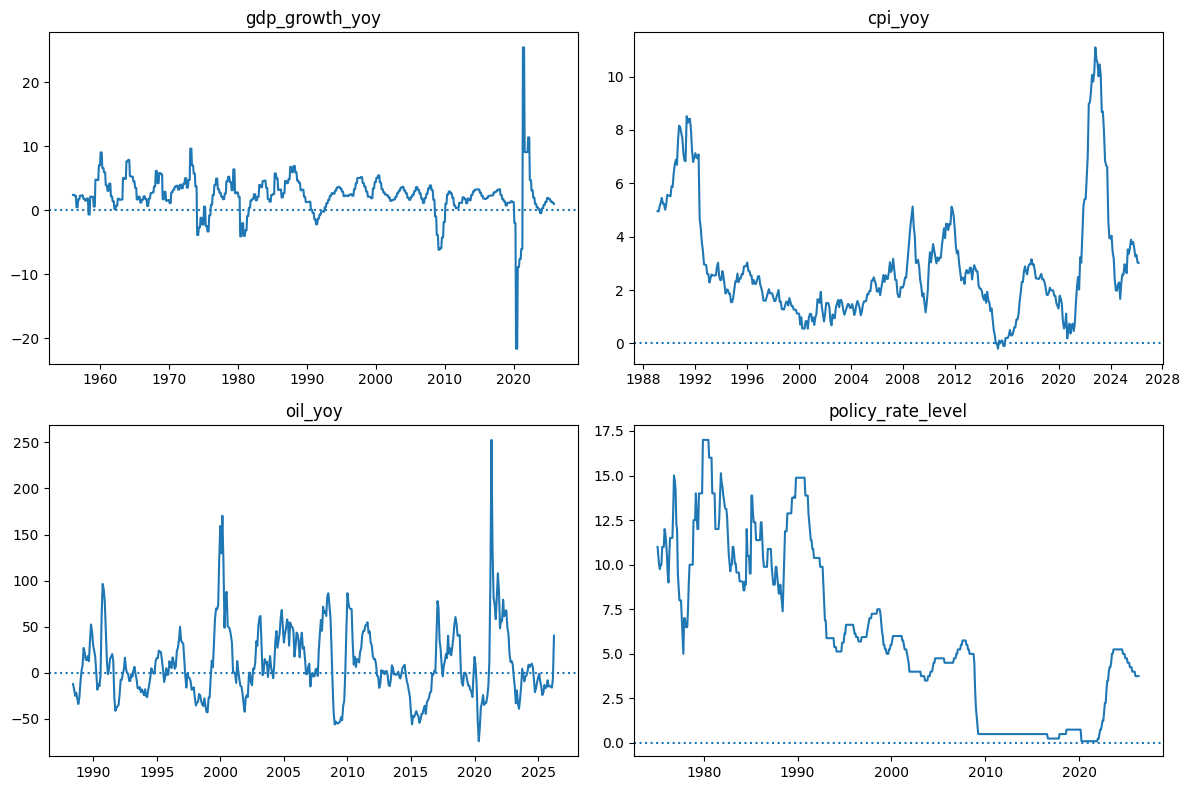

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), signals.columns):
    ax.plot(signals.index, signals[col])
    ax.axhline(0, linestyle=":")
    ax.set_title(col)

plt.tight_layout()
plt.show()

# GDP and oil oscillating around 0
# inflation clearly in the ascendancy
# Policy Rate on a short term decline
# Does that matter for later scoring?

In [64]:
absolute_values
signals

,gdp_growth_yoy,cpi_yoy,oil_yoy,policy_rate_level
1955-01-31,NaN,NaN,NaN,NaN
1955-02-28,NaN,NaN,NaN,NaN
1955-03-31,NaN,NaN,NaN,NaN
1955-04-30,NaN,NaN,NaN,NaN
1955-05-31,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-12-31,NaN,3.318584,-15.319917,3.75
2026-01-31,NaN,3.028065,-15.980826,3.75
2026-02-28,NaN,3.014706,-6.032769,3.75
2026-03-31,NaN,NaN,40.256909,3.75


# Step 3: Devise a Composite Metric

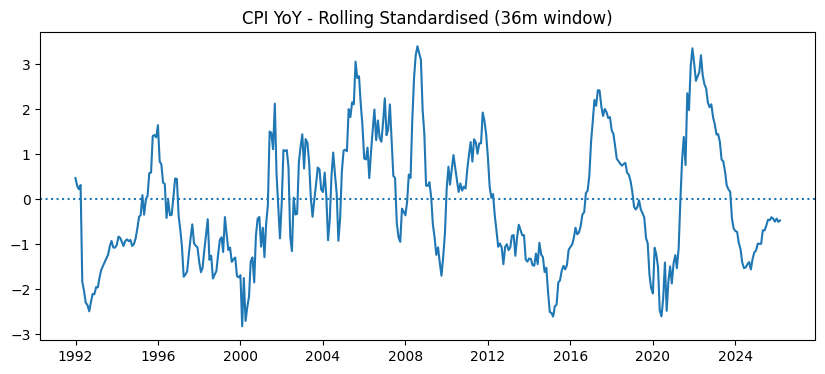

In [25]:
## Standardise one signal manually

cpi_signal = signals["cpi_yoy"].dropna()

window = 36  # 36 months (~3 years)

rolling_mean = cpi_signal.rolling(window).mean()
rolling_std = cpi_signal.rolling(window).std()

cpi_z = (cpi_signal - rolling_mean) / rolling_std

plt.figure(figsize=(10, 4))
plt.plot(cpi_z.index, cpi_z.values)
plt.axhline(0, linestyle=":")
plt.title(f"CPI YoY - Rolling Standardised ({window}m window)")
plt.show()

# Why standardise at all
# So instead of: “CPI is 6%”, you get “CPI is +1.8 standard deviations above normal”

# Why is CPI in percent not directly comparable to policy rate in percent?
# CPI YoY measures a rate of change (velocity) and policy rate measures a level
# It's how fast prices are rising vs the cost of money right now


In [29]:
# Standardise all signals

z = pd.DataFrame(index=signals.index)

for col in signals.columns:
    s = signals[col]
    z[col] = (s - s.rolling(36).mean()) / s.rolling(36).std()

# We're assuming
# Stationarity (a stable normal that doesn't change over time)
# Symmetry (upside deviations are equal to downside deviations)
# Normal distribution (most values cluster nicely, extremes are rare)
# Independence over time (no path dependency)

# If CPI sits at 2% for a long time, and suddenly spikes to 10% as it did in 2022, the mean shifts upwards, the
# standard deviation explodes, and previous years look suddenly calm in comparison

In [31]:
# Flip the signs where 'higher = worse'

z_adj = z.copy()

z_adj["cpi_yoy"] = -z_adj["cpi_yoy"]
z_adj["oil_yoy"] = -z_adj["oil_yoy"]
z_adj["policy_rate_level"] = -z_adj["policy_rate_level"]
# gdp growth stays positive because higher growth is better

# For the composite metric this is key. Building without this would create a signal that cancels itself out.
# Rising inflation, oil prices and interest rates means tightening of the economy, not prosperity

In [40]:
# Build a simple composite metric

numeric_cols = z_adj.select_dtypes(include="number").columns

z_adj["composite"] = z_adj[numeric_cols].mean(axis=1)

meta = pd.DataFrame(index=z_adj.index)

def contributing_cols(row):
    return [col for col in numeric_cols if pd.notna(row[col])]

meta["contributors"] = z_adj[numeric_cols].apply(contributing_cols, axis=1)

In [41]:
def active_contributors(row, threshold=0.5):
    return [col for col in numeric_cols if pd.notna(row[col]) and abs(row[col]) > threshold]

meta["active_contributors"] = z_adj[numeric_cols].apply(active_contributors, axis=1)

z_adj[["composite"]].join(meta).tail()

# Why use a mean? Because it's easy

# Each variable should not have equal weight:
# At different times, inflation dominates everything (2022), rates dominate everything (tightening cycles),
# growth dominates everything (recessions) and liquidity dominates everything (QE cycles)

# We lose insight on competing variables when rolling into one number
# We also lose causality, regime shifts and non-linear effects


,composite,contributors,active_contributors
2025-12-31,0.851461,"[cpi_yoy, oil_yoy, policy_rate_level, composite]","[policy_rate_level, composite]"
2026-01-31,0.906077,"[cpi_yoy, oil_yoy, policy_rate_level, composite]","[cpi_yoy, policy_rate_level, composite]"
2026-02-28,0.614673,"[cpi_yoy, oil_yoy, policy_rate_level, composite]","[policy_rate_level, composite]"
2026-03-31,-0.868654,"[oil_yoy, policy_rate_level, composite]","[oil_yoy, policy_rate_level, composite]"
2026-04-30,1.603239,"[policy_rate_level, composite]","[policy_rate_level, composite]"


In [48]:
# Consider: weighted versions, for example

weights = {
    "cpi_yoy": 0.4,
    "policy_rate_level": 0.3,
    "gdp_growth_yoy": 0.2,
    "oil_yoy": 0.1
}

z_adj["weighted_composite"] = sum(z_adj[col] * w for col, w in weights.items())

# Better: build multiple composites 
# Inflation pressure index, Growth momentum index, Liquidity index

In [46]:
z_adj.tail(10)

,gdp_growth_yoy,cpi_yoy,oil_yoy,policy_rate_level,composite,contributors
2025-07-31,0.129571,0.461415,0.621248,0.259580,0.367953,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate..."
2025-08-31,0.204726,0.471090,0.531340,0.681429,0.472146,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate..."
2025-09-30,0.297767,0.404923,-0.036054,0.838477,0.376278,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate..."
2025-10-31,0.030782,0.441157,0.400171,1.074833,0.486736,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate..."
2025-11-30,NaN,0.502231,0.320702,1.238024,0.686986,"[cpi_yoy, oil_yoy, policy_rate_level]"
2025-12-31,NaN,0.436164,0.368415,1.749806,0.851461,"[cpi_yoy, oil_yoy, policy_rate_level]"
2026-01-31,NaN,0.509612,0.397148,1.811471,0.906077,"[cpi_yoy, oil_yoy, policy_rate_level]"
2026-02-28,NaN,0.477654,-0.394427,1.760793,0.614673,"[cpi_yoy, oil_yoy, policy_rate_level]"
2026-03-31,NaN,NaN,-3.415419,1.678110,-0.868654,"[oil_yoy, policy_rate_level]"
2026-04-30,NaN,NaN,NaN,1.603239,1.603239,[policy_rate_level]


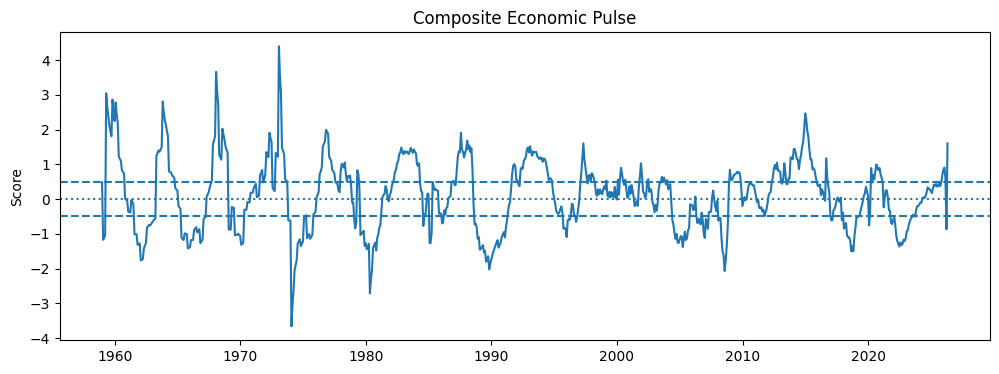

In [49]:
# Plot the composite

plt.figure(figsize=(12, 4))
plt.plot(z_adj.index, z_adj["composite"])
plt.axhline(0.5, linestyle="--")
plt.axhline(0, linestyle=":")
plt.axhline(-0.5, linestyle="--")
plt.title("Composite Economic Pulse")
plt.ylabel("Score")
plt.show()

# Multiple boom/bust cycles in the 20th century, with higher nominal growth, more active rate cycles and less QE
# Higher volatility in the dot-com bubble, much more oil volatility and monetary tightening then easing
# 2007 and COVID crises showing clearly
# 2017 looks overly healthy, because of low inflation, moderate growth and ultra-loose monetary policy

# The highs of this century do not match last century
# Pre-2000: Higher inflation tolerance, higher rates, more aggressive cycles, less intervention
# Post-2008: Lower growth, lower rates, heavy central bank intervention, suppressed volatility (until it breaks)

In [55]:
# Ensure separation
cols = ["gdp_growth_yoy", "cpi_yoy", "oil_yoy", "policy_rate_level"]

z_adj = z_adj.drop(columns=["contributors"], errors="ignore")

meta = meta.rename(columns={"contributors": "signal_contributors"})

view = (
    z_adj.loc["2016":"2018", cols + ["composite"]]
    .join(meta)
)

view.head(20)

# Looks like the data is wrong

,gdp_growth_yoy,cpi_yoy,oil_yoy,policy_rate_level,composite,signal_contributors,active_contributors
2016-01-31,-0.588367,1.008912,0.699569,NaN,0.373372,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]","[gdp_growth_yoy, cpi_yoy, oil_yoy]"
2016-02-29,-0.652490,0.868472,1.042527,NaN,0.419503,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]","[gdp_growth_yoy, cpi_yoy, oil_yoy]"
2016-03-31,-0.725829,0.637912,0.435080,NaN,0.115721,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]","[gdp_growth_yoy, cpi_yoy]"
2016-04-30,-0.291485,0.785492,0.348478,NaN,0.280829,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]",[cpi_yoy]
2016-05-31,-0.314087,0.742170,0.185697,NaN,0.204594,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]",[cpi_yoy]
2016-06-30,-0.337444,0.601189,-0.105110,NaN,0.052878,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]",[cpi_yoy]
2016-07-31,-0.289483,0.342468,-0.189921,NaN,-0.045646,"[gdp_growth_yoy, cpi_yoy, oil_yoy, composite]",[]
2016-08-31,-0.336870,0.296772,-1.103310,5.833333,1.172481,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate...","[oil_yoy, policy_rate_level, composite]"
2016-09-30,-0.388991,-0.131725,-1.069552,4.065437,0.618792,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate...","[oil_yoy, policy_rate_level, composite]"
2016-10-31,-0.348327,-0.184705,-1.268611,3.270236,0.367148,"[gdp_growth_yoy, cpi_yoy, oil_yoy, policy_rate...","[oil_yoy, policy_rate_level]"


In [57]:
# Verdict rule

latest_score = z_adj["composite"].dropna().iloc[-1]

if latest_score >= 0.5:
    verdict = "Expansion"
elif latest_score <= -0.5:
    verdict = "Contraction"
else:
    verdict = "Neutral"

latest_score, verdict

# Why -0.5 and 0.5

(np.float64(1.603238977941396), 'Expansion')

In [58]:
# Interpreration layer

latest = z_adj.dropna().iloc[-1]

summary = {
    "GDP growth": latest["gdp_growth_yoy"],
    "Inflation pressure": latest["cpi_yoy"],
    "Oil pressure": latest["oil_yoy"],
    "Rate pressure": latest["policy_rate_level"],
    "Composite": latest["composite"]
}

summary

# Is the verdict being driven by one feature too heavily?
# Which indicator dominates?
# Is that economically reasonable?

{'GDP growth': np.float64(0.030781997116237796),
 'Inflation pressure': np.float64(0.4411572458120158),
 'Oil pressure': np.float64(0.4001710611643743),
 'Rate pressure': np.float64(1.0748328588652387),
 'Composite': np.float64(0.4867357907394666)}

In [59]:
# Plain-English narrative

latest = z_adj.dropna().iloc[-1]

activity_view = "supportive" if latest["gdp_growth_yoy"] > 0 else "weak"
inflation_view = "cooling" if latest["cpi_yoy"] > 0 else "elevated"
rates_view = "supportive" if latest["policy_rate_level"] > 0 else "restrictive"

narrative = (
    f"Growth looks {activity_view}. "
    f"Inflation conditions look {inflation_view}. "
    f"Rates remain {rates_view}. "
    f"Overall verdict: {verdict}."
)

print(narrative)

Growth looks supportive. Inflation conditions look cooling. Rates remain supportive. Overall verdict: Expansion.
